In [69]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
%pip install numpy
%pip install pandas
%pip install pytest
%pip install jinja2

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrad

### Fibonacci Analysis

In [71]:
import pandas

from src.fish_stock import FishStock

fs = FishStock()

#get first 15 fibonacci numbers for analysis in this context
stock = fs.generate_fibonacci_list(15)
periods = range(1, 16)

df = pandas.DataFrame({"stock": stock}, index=pandas.Index(periods, name="period"))
df["growth_ratio"] = df["stock"] / df["stock"].shift(1)
df["pct_growth"] = df["stock"].pct_change() * 100

df

,stock,growth_ratio,pct_growth
period,,,
1,1,NaN,NaN
2,1,1.000000,0.000000
3,2,2.000000,100.000000
4,3,1.500000,50.000000
5,5,1.666667,66.666667
6,8,1.600000,60.000000
7,13,1.625000,62.500000
8,21,1.615385,61.538462
9,34,1.619048,61.904762


**Explanation:**
The Fibonacci model assumes the fish stock keeps growing forever, but real fish populations can't. Their growth is held back by how much food there is, the size of the habitat, parasites and disease, water levels and predators.

The model also has no way to account for fish being caught. So it can't show the real state of the stock or how much the cooperative can safely harvest.

The Schaefer (logistic) model is a better fit. It subtracts the harvest each period and caps growth at a carrying capacity, K, which is the largest stock the lake can support.

### Logistic growth model

In [72]:
import pandas 

fs_model = FishStock()
fs_model.harvest_portion = 0.2
df = pandas.DataFrame.from_dict(fs_model.simulate(52), orient='index')
df.round(1)

,stock,growth,catch,current_stock
1,4000.0,960.0,800.0,4160.0
2,4160.0,971.8,832.0,4299.8
3,4299.8,980.4,860.0,4420.2
4,4420.2,986.6,884.0,4522.7
5,4522.7,990.9,904.5,4609.1
6,4609.1,993.9,921.8,4681.1
7,4681.1,995.9,936.2,4740.8
8,4740.8,997.3,948.2,4790.0
9,4790.0,998.2,958.0,4830.2
10,4830.2,998.8,966.0,4863.0


### Price Model

In [73]:
from src.price_model import PriceModel

prices = PriceModel().simulate(52)

price_table = pandas.DataFrame({
    "week": list(prices.keys()),
    "price (UGX)": list(prices.values()),
})
price_table

,week,price (UGX)
0,1,12000
1,2,12150
2,3,12010
3,4,12210
4,5,11790
5,6,12290
6,7,12230
7,8,12390
8,9,12620
9,10,12690


###  Mean, median, variance, standard deviation and coefficient of variation (CV)

In [74]:
import statistics

kgs_in_1_tonne = 1000

fish = FishStock()
fish.harvest_portion = 0.2
stock_data = fish.simulate(52)

prices = PriceModel().simulate(52)

revenue = [stock_data[week]['catch'] * kgs_in_1_tonne * prices[week]
           for week in stock_data]

mean_rev = statistics.mean(revenue)
median_rev = statistics.median(revenue)
var_rev = statistics.variance(revenue)     
sd_rev = statistics.stdev(revenue)         
cv_rev = sd_rev / mean_rev                 

print(f"Mean:     {mean_rev:,.0f} UGX")
print(f"Median:   {median_rev:,.0f} UGX")
print(f"Variance: {var_rev:.0f} UGX²")
print(f"Std dev:  {sd_rev:,.0f} UGX")
print(f"CV:       {cv_rev:.2%}")

Mean:     10,428,126,641 UGX
Median:   10,324,000,581 UGX
Variance: 890993489937779200 UGX²
Std dev:  943,924,515 UGX
CV:       9.05%


**Conclusion**
 Variance is in "square shillings," which isn't practical and not a real amount of money, so a limit of 50,000 doesn't translate to the real world
 Co-efficient of variance is more meaningful because it can be expressed as a simple percentage, and we can say weekly income changes by about 9%

### Risk Assesor

In [75]:
from src.risk_assesor import RiskAssessor

assessor = RiskAssessor(fish, PriceModel())
results = assessor.run()

median_cv = results["weekly_cv"].median()
var_5 = assessor.value_at_risk(results["annual_revenue"])

print(f"Median weekly CV: {median_cv:.1%} -> {assessor.classify(median_cv)}")
print(f"Expected annual revenue: {results['annual_revenue'].mean():,.0f} UGX")
print(f"5% VaR (annual revenue): {var_5:,.0f} UGX")

Median weekly CV: 7.5% -> LOW
Expected annual revenue: 613,326,119,589 UGX
5% VaR (annual revenue): 518,740,939,594 UGX


**Conclusion**

We simulated 1,000 years of trading, each with fish prices rising and falling in a different way.

Weekly income usually shifts by only 7 or 8%, which is fairly steady, so the risk is rated low. In a normal year the cooperative earns about 613 billion UGX. About one year in 20 is a bad one, bringing in 519 billion UGX or less, roughly 95 billion below normal.

So income is mostly stable, but the cooperative should plan for the occasional year that earns about 15% less.

### Scenario Analysis

In [76]:
r, K = 0.4, 10_000
msy = r * K / 4   # 1,000 t per week

rows = []
for h in [0.05, 0.10, 0.20, 0.30]:
    fssh = FishStock()
    fssh.harvest_portion = h
    stock_data = fssh.simulate(52)

    assessor = RiskAssessor(fssh, PriceModel())
    results = assessor.run()
    median_cv = results["weekly_cv"].median()

    rows.append({
        "h": h,
        "final stock (t)": stock_data[52]["current_stock"],
        "final weekly catch (t)": stock_data[52]["catch"],
        "% of MSY": stock_data[52]["catch"] / msy,
        "total revenue (bn UGX)": results["annual_revenue"].mean() / 1e9,
        "median CV": median_cv,
        "risk": assessor.classify(median_cv),
    })

pandas.DataFrame(rows)

,h,final stock (t),final weekly catch (t),% of MSY,total revenue (bn UGX),median CV,risk
0,0.05,8749.999997,437.500000,0.437500,261.829062,0.135783,MODERATE
1,0.10,7499.999925,749.999989,0.750000,450.499654,0.120976,MODERATE
2,0.20,4999.987936,999.996984,0.999997,613.326120,0.074542,LOW
3,0.30,2503.717309,751.239330,0.751239,511.699143,0.135136,MODERATE


**Conclusion**

The old model couldn't answer either of the cooperative's questions. Its Fibonacci numbers let the fish grow forever, with no limit and no fishing. Its 50,000 variance limit would flag every scenario as risky, because variance is measured in square shillings. A logistic growth model and the coefficient of variation fix both problems. Catching about 20% of the stock each week is sustainable: it keeps the lake half full and gives the maximum sustainable yield of 1,000 tonnes a week. At that rate, weekly income usually moves by only 7 or 8%, so revenue risk is low. The cooperative should still plan for a bad year, about one in 20, when income drops roughly 15% to 519 billion UGX. It should also fish a little below 20%, since the growth and capacity figures in the model are estimates.

## Stock Trajectories, Chart A

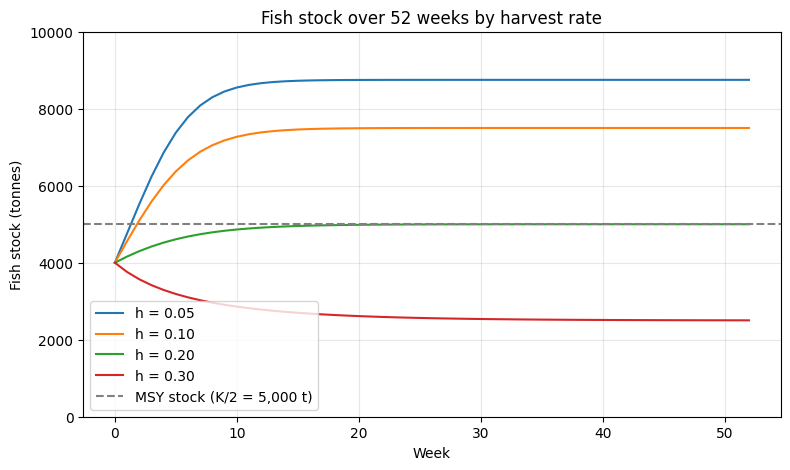

In [77]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

for h in [0.05, 0.10, 0.20, 0.30]:
    fsh = FishStock()
    fsh.harvest_portion = h
    stock_data = fsh.simulate(52)

    # Week 0 is the starting stock; weeks 1-52 are the end-of-week stock
    weeks = [0] + list(stock_data.keys())
    stock = [fsh.start_capacity] + [row["current_stock"] for row in stock_data.values()]
    ax.plot(weeks, stock, label=f"h = {h:.2f}")

ax.axhline(fsh.max_capacity / 2, color="grey", linestyle="--",
           label="MSY stock (K/2 = 5,000 t)")
ax.set_xlabel("Week")
ax.set_ylabel("Fish stock (tonnes)")
ax.set_title("Fish stock over 52 weeks by harvest rate")
ax.set_ylim(0, 10_000)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Annual revenue histogram with VAR, chart B

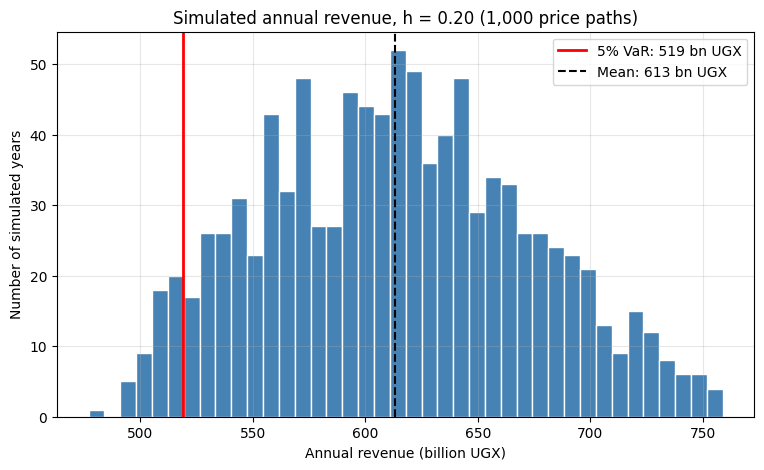

In [78]:
f = FishStock()
f.harvest_portion = 0.2

assessor = RiskAssessor(f, PriceModel())
results = assessor.run()

annual_bn = results["annual_revenue"] / 1e9
var_bn = assessor.value_at_risk(results["annual_revenue"]) / 1e9
mean_bn = annual_bn.mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(annual_bn, bins=40, color="steelblue", edgecolor="white")
ax.axvline(var_bn, color="red", linewidth=2, label=f"5% VaR: {var_bn:,.0f} bn UGX")
ax.axvline(mean_bn, color="black", linestyle="--", label=f"Mean: {mean_bn:,.0f} bn UGX")
ax.set_xlabel("Annual revenue (billion UGX)")
ax.set_ylabel("Number of simulated years")
ax.set_title("Simulated annual revenue, h = 0.20 (1,000 price paths)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Conclusion**
In chart (A), each line levels off at its own resting point, K(1 − h/r). Only h = 0.20 settles on the dashed 5,000 t line, where the catch is highest. The two light rates fill the lake up, while h = 0.30 drains it to a quarter full.

In chart (B), each bar counts how many of the 1,000 simulated years earned that much. The red line is the 5% VaR. Exactly 50 of the 1,000 years (5%) fall to its left, which confirms the calculation. The spread from about 480 to 760 billion UGX is the price risk the cooperative faces.

## Closed season fish stock

In [79]:
from src.closed_season_fish_stock import ClosedSeasonFishStock

WEEKS = 5 * 52
rows = []
for label, model_class in [("open all year", FishStock),
                           ("8-week closed season", ClosedSeasonFishStock)]:
    for h in [0.10, 0.20, 0.30]:
        fish = model_class()
        fish.harvest_portion = h
        catch = [row["catch"] for row in fish.simulate(WEEKS).values()]

        assessor = RiskAssessor(fish, PriceModel(), weeks=WEEKS)
        results = assessor.run()
        rows.append({
            "scenario": label, "h": h,
            "5-yr revenue (bn UGX)": results["annual_revenue"].mean() / 1e9,
            "5% VaR (bn UGX)": assessor.value_at_risk(results["annual_revenue"]) / 1e9,
            "year-5 catch (t)": sum(catch[-52:]),
        })
pandas.DataFrame(rows)

,scenario,h,5-yr revenue (bn UGX),5% VaR (bn UGX),year-5 catch (t)
0,open all year,0.1,2370.640526,1960.733057,39000.000000
1,open all year,0.2,3173.513802,2626.814827,52000.000000
2,open all year,0.3,2431.976233,2019.022032,39000.000001
3,8-week closed season,0.1,2064.576355,1706.618647,33682.100415
4,8-week closed season,0.2,2891.174615,2389.343102,47164.643553
5,8-week closed season,0.3,2578.559797,2132.644334,41995.734648


**Conclusion**

At the 0.20 fishing level, an 8-week break each year cuts income by about 9% over 5 years, roughly 283 billion UGX. The lake is already at its best level, so the break just lets it overfill, and the fish almost stop multiplying. With heavy fishing (0.30), though, the break helps, because it lets an overfished lake recover. Our model can't show the main reason for closed seasons, which is protecting fish while they breed, so it shows the cost but not the benefit.